# WEEK 2 :
Simulation & Fix Effect

In [1]:
# Step 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df1 = pd.read_csv("homework_2.1.csv")
df1.head()

,time,G1,G2,G3
0,0,0.882026,1.441575,0.065409
1,1,0.210079,-0.163880,0.140310
2,2,0.509369,-0.115242,0.819830
3,3,1.150447,1.014698,0.607632
4,4,0.973779,-0.046562,0.610066


In [2]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    100 non-null    int64  
 1   G1      100 non-null    float64
 2   G2      100 non-null    float64
 3   G3      100 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 3.3 KB


In [3]:
df1.describe()

,time,G1,G2,G3
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,0.524904,1.036006,0.715384
std,29.011492,0.561614,0.552593,0.581227
min,0.000000,-1.076495,-0.163880,-0.508478
25%,24.750000,0.186046,0.621088,0.298386
50%,49.500000,0.464842,1.006778,0.643041
75%,74.250000,0.947191,1.427074,1.125461
max,99.000000,1.862935,2.561618,2.321958


In [4]:
df1.isnull().sum()

time    0
G1      0
G2      0
G3      0
dtype: int64

In [5]:
df1.duplicated().sum()

np.int64(0)

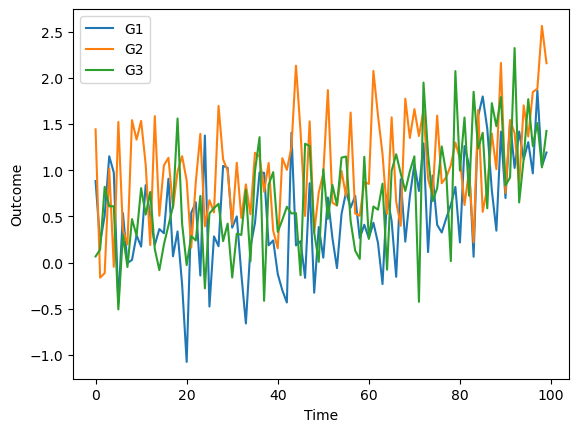

In [7]:
# Step 2: Visualize the three groups over time

plt.plot(df1["time"], df1["G1"], label="G1")
plt.plot(df1["time"], df1["G2"], label="G2")
plt.plot(df1["time"], df1["G3"], label="G3")

plt.xlabel("Time")
plt.ylabel("Outcome")
plt.legend()
plt.show()

In [8]:
# Step 3 :Reshape data from wide to long format

df_long = df1.melt(
    id_vars="time",
    value_vars=['G1','G2','G3'],
    var_name='group',
    value_name="outcome"
)
df_long.head(10)

,time,group,outcome
0,0,G1,0.882026
1,1,G1,0.210079
2,2,G1,0.509369
3,3,G1,1.150447
4,4,G1,0.973779
5,5,G1,-0.438639
6,6,G1,0.535044
7,7,G1,-0.005679
8,8,G1,0.028391
9,9,G1,0.295299


In [9]:
# Step 4: Estimate group fixed effects with one common time slope

import statsmodels.formula.api as smf

model = smf.ols(
    "outcome ~ time + C(group) - 1",  # -1 just remove global intercept 
    data = df_long
).fit()

model.params

C(group)[G1]    0.078552
C(group)[G2]    0.589654
C(group)[G3]    0.269032
time            0.009017
dtype: float64

In [10]:
# Step 5: Regression with global intercept and group indicators

model_reference = smf.ols(
    "outcome ~ time +C(group)",
    data=df_long
).fit()
model_reference.params

Intercept         0.078552
C(group)[T.G2]    0.511102
C(group)[T.G3]    0.190480
time              0.009017
dtype: float64

In [11]:
# Step 6: Estimate the linear coefficient for Group 1

model_g1 = smf.ols(
    "G1 ~ time",
    data=df1
).fit()
model_g1.params

Intercept    0.104236
time         0.008498
dtype: float64

# Dataset 2

In [12]:
# Step 1 

df2 = pd.read_csv("homework_2.2.csv")
df2.head()

,X,Y,Z
0,0,1.182435,-0.725820
1,0,2.714474,0.563476
2,0,0.077612,-0.435632
3,0,-0.154449,-0.104553
4,0,22.298992,-2.321273


In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       10000 non-null  int64  
 1   Y       10000 non-null  float64
 2   Z       10000 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


In [14]:
df2.describe()

,X,Y,Z
count,10000.000000,10000.000000,10000.000000
mean,0.197200,5.498005,-0.000690
std,0.397905,7.307418,0.990785
min,0.000000,-0.200000,-3.694285
25%,0.000000,0.608725,-0.663618
50%,0.000000,3.080435,-0.010368
75%,0.000000,7.378477,0.669695
max,1.000000,71.935798,3.598310


In [15]:
df2.isnull().sum()

X    0
Y    0
Z    0
dtype: int64

In [16]:
df2.duplicated().sum()

np.int64(0)

In [17]:
df2['X'].value_counts()

X
0    8028
1    1972
Name: count, dtype: int64

In [18]:
# Step 2:Calculate the naive treatment effect

treated_mean = df2[df2['X'] == 1]['Y'].mean()
untreated_mean = df2[df2['X'] == 0]['Y'].mean()

print("Treated mean:", treated_mean)
print("Untreated mean:", untreated_mean)

Treated mean: 7.842756767343214
Untreated mean: 4.922039502620024


In [19]:
treated_mean - untreated_mean

np.float64(2.9207172647231907)

In [20]:
# Step 3: Create one bootstrap sample

bootstrap_sample = df2.sample(
    n=len(df2),
    replace=True
)
bootstrap_sample.head()

,X,Y,Z
5418,0,-0.118917,-0.072655
3712,0,-0.199708,-0.207642
5784,0,1.739154,-0.822761
343,0,15.624095,-1.978994
5928,0,0.121320,0.053503


In [21]:
# Step 4: Calculate the effect in one bootstrap sample

boot_treated_mean = bootstrap_sample[
    bootstrap_sample["X"] == 1
]["Y"].mean()

boot_untreated_mean = bootstrap_sample[
    bootstrap_sample["X"] == 0
]["Y"].mean()

boot_effect = boot_treated_mean - boot_untreated_mean

print("Bootstrap treated mean:", boot_treated_mean)
print("Bootstrap untreated mean:", boot_untreated_mean)
print("Bootstrap effect:", boot_effect)

Bootstrap treated mean: 7.752714489193081
Bootstrap untreated mean: 5.009520254859559
Bootstrap effect: 2.7431942343335214


In [26]:
# Step 5: Run bootstrap simulation

bootstrap_effects =[]
for i in range(1000):
     sample=df2.sample(
         n=len(df2),
         replace=True
     )
     treated = sample[sample["X"] == 1]["Y"].mean()
     untreated = sample[sample['X'] == 0]['Y'].mean()

     effect = treated - untreated

     bootstrap_effects.append(effect)
     

In [27]:
len(bootstrap_effects)

1000

In [28]:
bootstrap_effects[:10]

[np.float64(2.8820073324157036),
 np.float64(3.045761595279812),
 np.float64(3.1944456048866456),
 np.float64(3.1856081097476627),
 np.float64(3.024468425352544),
 np.float64(2.683135630618727),
 np.float64(3.148274744137767),
 np.float64(3.0713202004121722),
 np.float64(3.01038708518794),
 np.float64(2.895921551379983)]

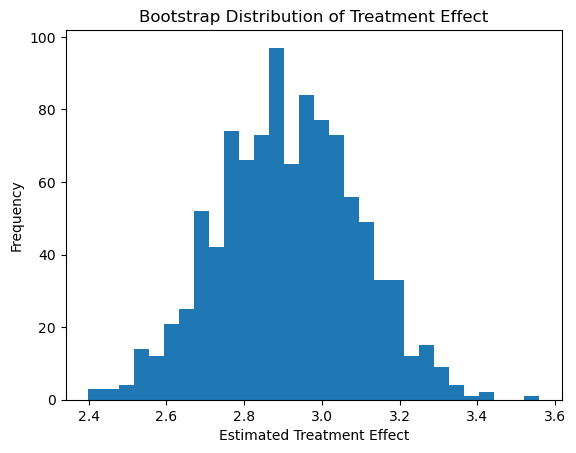

In [29]:
# Step 6: Visualize the bootstrap distribution

plt.hist(bootstrap_effects, bins=30)

plt.xlabel("Estimated Treatment Effect")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Treatment Effect")

plt.show()

In [30]:
# Calculate the variance of the bootstrap effects
bootstrap_variance = np.var(bootstrap_effects)
bootstrap_variance

np.float64(0.031922854025493594)

In [31]:
# Step 7: Estimate treatment effect using linear regression

reg_model = smf.ols(
    "Y ~ X",
    data=df2,
).fit()
reg_model.params

Intercept    4.922040
X            2.920717
dtype: float64

In [37]:
# Step 8: Bootstrap the regression treatment effect

regression_effects = []

for i in range(10000):
    sample = df2.sample(
        n = len(df2),
        replace=True
    )
    model = smf.ols(
        "Y ~ X",
        data=sample
    ).fit()

    effect = model.params["X"]
    regression_effects.append(effect)

In [38]:
len(regression_effects)

10000

In [39]:
regression_effects[:10]

[np.float64(3.1796130992889977),
 np.float64(2.633587951893823),
 np.float64(2.9029882341053646),
 np.float64(2.671577061683611),
 np.float64(3.022397110338391),
 np.float64(2.672325041944018),
 np.float64(3.001570709354556),
 np.float64(3.1909079155121813),
 np.float64(3.263349203753522),
 np.float64(3.1778320858257296)]

In [40]:
# Step 9: Calculate skewness of regression treatment effects 

from scipy.stats import skew
regression_skewness = skew(regression_effects)
regression_skewness

np.float64(0.0024929432745265656)

In [41]:
# Step 11: Regression controlling for the confounder Z

reg_model_adjusted = smf.ols(
    "Y ~ X + Z",
    data=df2
).fit()

reg_model_adjusted.params

Intercept    4.943624
X            2.818696
Z            2.124724
dtype: float64

In [42]:
# Step 12: Bootstrap adjusted regression

adjusted_effects = []

for i in range(10000):
    sample = df2.sample(
        n=len(df2),
        replace=True
    )

    model = smf.ols(
        "Y ~ X + Z",
        data=sample
    ).fit()

    effect = model.params["X"]
    adjusted_effects.append(effect)

In [43]:
# Calculate skewness

adjusted_skewness = skew(adjusted_effects)
adjusted_skewness

np.float64(0.07746790569813618)

In [44]:
# Bootstrap linear regression effects and calculate skewness

from scipy.stats import skew
import numpy as np
import statsmodels.formula.api as smf

rng = np.random.default_rng(42)

regression_effects = []

for i in range(10000):
    idx = rng.choice(len(df2), size=len(df2), replace=True)
    sample = df2.iloc[idx]

    model = smf.ols("Y ~ X", data=sample).fit()
    regression_effects.append(model.params["X"])

regression_skewness = skew(regression_effects)

regression_skewness

np.float64(0.049896968536616446)

## Summary and Key Takeaways

In this notebook, I explored how different methods can be used to estimate and evaluate treatment effects. The main focus was on comparing groups, using bootstrap simulation to measure uncertainty, and using linear regression to estimate treatment effects.

### 1. Exploring the Data

I started by loading and inspecting the datasets to understand their structure, variables, and basic characteristics. I checked the number of observations, summary statistics, missing values, duplicates, and the distribution of the treatment variable.

This initial exploration helped me understand what the treatment and outcome variables represented before estimating any effects.

### 2. Estimating the Treatment Effect

A simple way to estimate the treatment effect is to compare the average outcome of the treated group with the average outcome of the untreated group:

**Estimated Effect = Mean(Y | X = 1) - Mean(Y | X = 0)**

This provides a straightforward estimate of the difference between the two groups.

However, this difference should not automatically be interpreted as a causal effect. Other variables may influence both treatment assignment and the outcome.

### 3. Bootstrap Resampling

Next, I used bootstrap simulation to understand how stable the estimated treatment effect is.

The bootstrap procedure follows these steps:

1. Draw a new sample from the observed data **with replacement**.
2. Keep the bootstrap sample the same size as the original dataset.
3. Recalculate the treatment effect.
4. Repeat the process many times.
5. Examine the distribution of the resulting estimates.

Instead of relying on only one estimate from the original dataset, bootstrap simulation gives us a distribution of possible estimates.

### 4. Understanding the Bootstrap Distribution

The bootstrap distribution helps us understand the uncertainty and stability of an estimator.

A narrow distribution suggests that the estimator is relatively stable across repeated samples, while a wider distribution indicates greater sampling variability.

The variance or standard deviation of the bootstrap estimates can therefore be used to describe the uncertainty of the estimator.

An important idea is that bootstrap resampling does **not** create new independent information. It uses the observed sample as an approximation of the unknown population.

### 5. Linear Regression as an Effect Estimator

I also estimated the treatment effect using a linear regression with an intercept:

**Y = β₀ + β₁X + ε**

When `X` is binary:

- **β₀** represents the expected outcome for the untreated group.
- **β₁** represents the difference in the expected outcome between the treated and untreated groups.

Therefore, in this simple regression, the coefficient on `X` corresponds to the difference in group means.

### 6. Bootstrapping the Regression Estimate

I then combined regression with bootstrap simulation.

For every bootstrap sample, I fitted the regression again and stored the estimated coefficient of `X`. Repeating this process thousands of times produced a bootstrap distribution of the regression treatment-effect estimate.

This allowed me to study not only the estimated effect itself, but also how much the regression estimate changes across resampled datasets.

### 7. Skewness and the Shape of the Sampling Distribution

Finally, I calculated the **skewness** of the bootstrap distribution.

Skewness measures the asymmetry of a distribution:

- Skewness ≈ 0 → approximately symmetric
- Positive skewness → longer right tail
- Negative skewness → longer left tail

A skewness value close to zero suggests that the bootstrap distribution of the regression treatment-effect estimator is approximately symmetric.

### 8. Confounding and Regression Adjustment

I also explored what happens when another variable, `Z`, is included in the regression:

**Y = β₀ + β₁X + β₂Z + ε**

Comparing the coefficient of `X` before and after controlling for `Z` demonstrates an important causal-inference idea: an observed difference between treated and untreated groups may partly reflect differences in other variables.

Regression adjustment can help account for observed confounders, although including a variable in a regression does not automatically guarantee a causal interpretation.

---

### Main Takeaway

The biggest lesson from this notebook is that estimating an effect is only the beginning.

A complete analysis should also ask:

**How stable is the estimate? How much would it change under repeated sampling? Is the sampling distribution symmetric? Could another variable be confounding the relationship?**

Bootstrap simulation provides a practical way to study the uncertainty of an estimator, while regression provides a flexible framework for estimating effects and adjusting for observed variables.

Together, these tools help move the analysis from simply calculating a difference toward understanding the reliability and interpretation of that difference.